<h3>E-Commerce Customer Churn Risk Prediction</h3>

<h5>Description</h5>
<ol>
    <li>Loading and exploring the e-commerce customer dataset (50,000 customers, 53 columns)</li>
    <li>Defining a real business target: identifying customers at <b>High churn risk</b></li>
    <li>Removing leaky / pre-computed score columns so the model learns from genuine raw signals only</li>
    <li>Cleaning, encoding, and scaling the data</li>
    <li>Fixing severe class imbalance with <b>SMOTE</b></li>
    <li>Training 5 models from a simple baseline up to boosted trees (Logistic Regression → Decision Tree → Random Forest → XGBoost → LightGBM)</li>
    <li>Comparing all models on Accuracy, Precision, Recall, F1 and ROC-AUC</li>
    <li>Looking at which features actually drive churn risk</li>
    <li>Final conclusion and business takeaways</li>
</ol>

<h4>Import Libraries</h4>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

<h4>Read the Dataset</h4>

In [2]:
df = pd.read_csv('E-commerce_Customer_Segmentation_2026.csv')
print("Shape :",df.shape)
df.head()

Shape : (50000, 53)


,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  object 
 1   customer_segment               50000 non-null  object 
 2   segment_category               50000 non-null  object 
 3   age                            50000 non-null  int64  
 4   age_group                      50000 non-null  object 
 5   gender                         50000 non-null  object 
 6   country                        50000 non-null  object 
 7   city                           50000 non-null  object 
 8   income_bracket                 50000 non-null  object 
 9   education_level                50000 non-null  object 
 10  employment_type                50000 non-null  object 
 11  marital_status                 50000 non-null  object 
 12  tenure_months                  50000 non-null 

<h4>Check Missing Values</h4>

In [9]:
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values" : missing,
    "Missing %" : (missing / len(df) * 100).round(2)
})

print("Missing Value Summary")
display(missing_summary.sort_values("Missing Values", ascending=False).head(15))

Missing Value Summary


,Missing Values,Missing %
preferred_category_3,33257,66.51
preferred_category_2,16743,33.49
social_media_presence,12420,24.84
loyalty_tier,1272,2.54
segment_category,0,0.00
age_group,0,0.00
age,0,0.00
gender,0,0.00
country,0,0.00
education_level,0,0.00


<h4>Check Duplicated Values</h4>

In [10]:
# Duplicate rows

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count:,}")

Duplicate Rows : 0


In [138]:
df['churn_risk_category'].value_counts()

churn_risk_category
Very Low     20604
Low          17203
Medium        9491
High          2395
Very High      307
Name: count, dtype: int64

<h4>Defining the Target: Churn Risk</h4>

In [3]:
df['high_churn_risk'] = df['churn_risk_category'].isin(['High', 'Very High']).astype(int)
print(df['high_churn_risk'].value_counts())
print()
print(df['high_churn_risk'].value_counts(normalize=True).round(3) * 100)

high_churn_risk
0    47298
1     2702
Name: count, dtype: int64

high_churn_risk
0    94.6
1     5.4
Name: proportion, dtype: float64


<h4>Check Duplicated Values</h4>

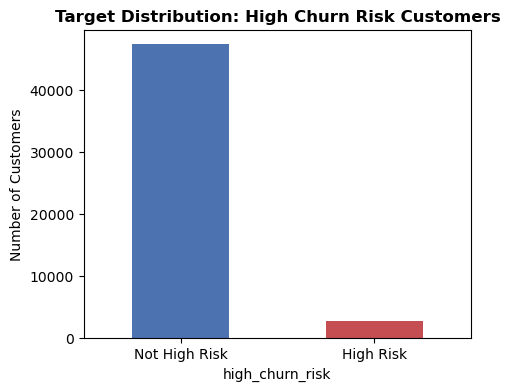

In [151]:
plt.figure(figsize=(5,4))
df['high_churn_risk'].value_counts().plot(kind='bar', color=['#4C72B0','#C44E52'])
plt.xticks([0,1], ['Not High Risk', 'High Risk'], rotation=0)
plt.title('Target Distribution: High Churn Risk Customers', fontweight='bold')
plt.ylabel('Number of Customers')
plt.show()

<h4> Avoiding Data Leakage</h4>

In [4]:
leaky_columns = [
    'segment_category', 'loyalty_tier', 'satisfaction_level', 'clv_category',
    'customer_value_category', 'recency_score', 'frequency_score', 'monetary_score',
    'rfm_score', 'rfm_category', 'churn_risk_score', 'customer_health_score',
    'health_status', 'activity_status', 'churn_risk_category', 'profitability_category',
    'engagement_level', 'behavior_segment', 'device_preference'
]

# also drop identifiers / very high-cardinality / constant columns that add no learnable signal
other_drops = ['customer_id', 'city', 'social_media_presence', 'dataset_year']

df.drop(columns = leaky_columns + other_drops, inplace=True)
print("Remaining Columns :",df.shape[1])
df.columns.tolist()

Remaining Columns : 31


['customer_segment',
 'age',
 'age_group',
 'gender',
 'country',
 'income_bracket',
 'education_level',
 'employment_type',
 'marital_status',
 'tenure_months',
 'total_purchases',
 'avg_order_value_usd',
 'total_spent_usd',
 'purchase_frequency',
 'days_since_last_purchase',
 'preferred_category_1',
 'preferred_category_2',
 'preferred_category_3',
 'shopping_channel',
 'device_used',
 'payment_method',
 'return_count',
 'complaint_count',
 'satisfaction_score',
 'email_open_rate',
 'click_through_rate',
 'conversion_rate',
 'customer_lifetime_value_usd',
 'customer_acquisition_cost_usd',
 'customer_profitability_usd',
 'high_churn_risk']

In [161]:
missing=df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

preferred_category_3    33257
preferred_category_2    16743
dtype: int64


<h4> Preprocessing </h4>

In [5]:
null_columns = ['preferred_category_3', 'preferred_category_2']

for col in null_columns:
    df[col] = df[col].fillna('None')

X = df.drop(columns=['high_churn_risk'])
y = df['high_churn_risk']

category_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns : {len(category_cols)}")
print(f"Numerical_columns : {len(numerical_cols)}")

Categorical columns : 15
Numerical_columns : 16


In [7]:
ss = StandardScaler()
le = LabelEncoder()

for col in category_cols:
    X[col] = le.fit_transform(X[col])

In [100]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

x_train_sc = ss.fit_transform(x_train)
x_test_sc = ss.transform(x_test)

print("Train shape :",x_train_sc.shape, " | Test shape :", x_test_sc.shape)

Train shape : (40000, 30)  | Test shape : (10000, 30)


<h4> Handling Class Imbalance with SMOTE</h4>

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_bal, y_train_bal = smote.fit_resample(x_train_sc, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE_2 :", np.bincount(y_train_bal))

Before SMOTE: [37838  2162]
After SMOTE_2 : [37838 37838]


<h4> Training Multiple Models - Baseline to Best</h4>

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                random_state=42, verbose=-1)
}

def evaluting_models(x_train,x_test,y_train,y_test):
    results = []
    trained_models = {}

    for name, model in models.items():
        model.fit(x_train, y_train)
        pred = model.predict(x_test)
        proba = model.predict_proba(x_test)[:, 1]

        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall': recall_score(y_test, pred),
            'F1-Score': f1_score(y_test, pred),
            'ROC-AUC': roc_auc_score(y_test, proba)
        })
        trained_models[name] = model
        print(f"{name} trained.")

    return results, trained_models

In [11]:
results, trained_models = evaluting_models(x_train_bal,x_test_sc,y_train_bal,y_test)

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
XGBoost trained.
LightGBM trained.


<h4> Comparing Model Performance</h4>

In [12]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.9721,0.7534,0.7185,0.7355,0.9878
1,LightGBM,0.9723,0.7583,0.7148,0.7359,0.9874
2,Random Forest,0.9619,0.6109,0.8111,0.6969,0.9832
3,Decision Tree,0.9543,0.5478,0.8815,0.6757,0.9645
4,Logistic Regression,0.8783,0.2917,0.8778,0.4379,0.9501


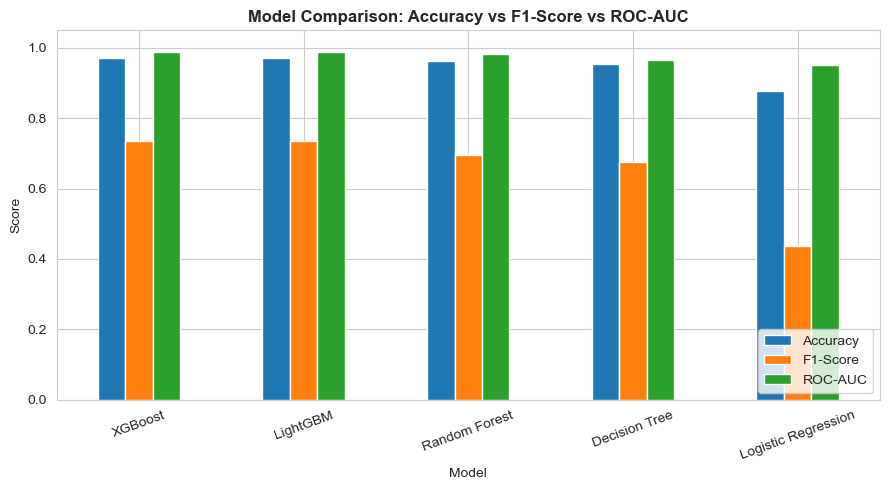

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df2.set_index('Model')[['Accuracy', 'F1-Score', 'ROC-AUC']].plot(kind='bar', ax=ax)
plt.title('Model Comparison: Accuracy vs F1-Score vs ROC-AUC',fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

<h4> Closer Look at the Best Model</h4>

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_pred = best_model.predict(x_test_sc)

print("Best model:", best_model_name)
print()
print(classification_report(y_test, best_pred, target_names=['Not High Risk', 'High Risk']))

Best model: XGBoost

               precision    recall  f1-score   support

Not High Risk       0.98      0.99      0.99      9460
    High Risk       0.75      0.72      0.74       540

     accuracy                           0.97     10000
    macro avg       0.87      0.85      0.86     10000
 weighted avg       0.97      0.97      0.97     10000



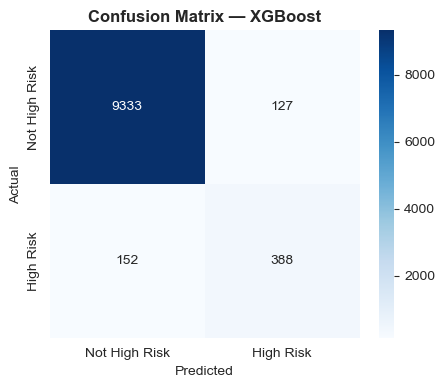

In [16]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High Risk','High Risk'],
            yticklabels=['Not High Risk','High Risk'])
plt.title(f'Confusion Matrix — {best_model_name}',fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

<h4> Checking Feature Importance</h4>

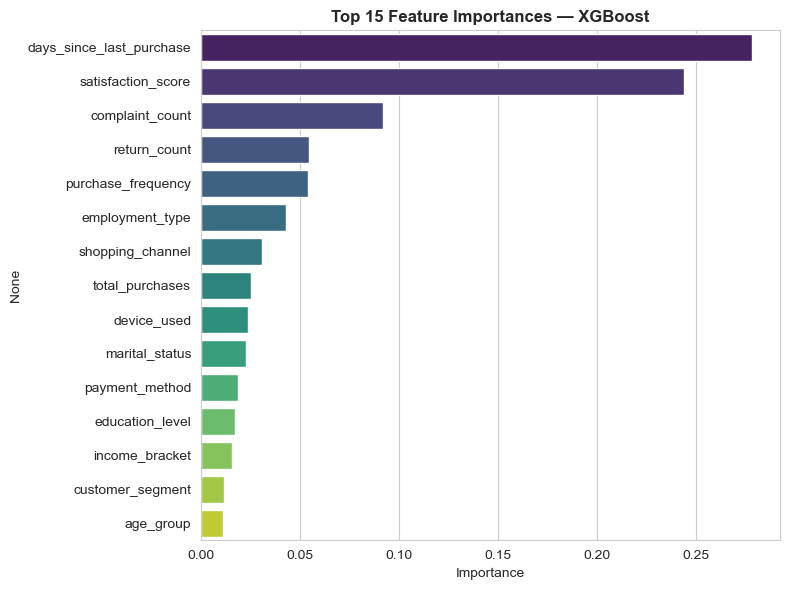

In [18]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title(f'Top 15 Feature Importances — {best_model_name}',fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

<h4> Keeping Only Few Important Features</h4>

In [44]:
selected_columns = [False, False, False, False, False, False, False, True, False, False, False, False, False, True, True,
                    False, False, False, True, False, False, True, True, True, False, False, False, False, False, False]

new_x_train_bal = x_train_bal[:,selected_columns]
new_x_test_sc = x_test_sc[:,selected_columns]

xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              eval_metric='logloss', random_state=42, n_jobs=-1)

xgb.fit(new_x_train_bal, y_train_bal)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

<h4> Evaluating XGBoost Model </h4>

In [59]:
y_pred = xgb.predict(new_x_test_sc)
proba = xgb.predict_proba(new_x_test_sc)[:, 1]

print(f"Accuracy : {round(accuracy_score(y_test,y_pred),3)}")
print(f"Precision : {round(precision_score(y_test,y_pred),3)}")
print(f"Recall : {round(recall_score(y_test,y_pred),3)}")
print(f"F1-Score : {round(f1_score(y_test,y_pred),3)}")
print(f"ROC-AUC-Score : {round(roc_auc_score(y_test, proba),3)}")

Accuracy : 0.971
Precision : 0.758
Recall : 0.672
F1-Score : 0.712
ROC-AUC-Score : 0.98


<h4> Converting Into Pickle File</h4>

In [70]:
import pickle

with open("churn_predict_model.pkl",'wb') as file:
    pickle.dump(xgb,file)
print('Model Converted.')

Model Converted.


<h4>Conclusion</h4>

<ul>
    <li>We built a <b>churn risk prediction model</b> for e-commerce customers, treating the top 5.4% highest risk customers as the positive class.</li>
    <li>We deliberately <b>removed leaky, pre-computed score columns</b> (churn_risk_score, rfm_score, customer_health_score, etc.) so the model learns from genuine, independently-collected behaviour — making the results trustworthy and realistic for a real deployment, not inflated by hidden shortcuts.</li>
    <li>Severe class imbalance (~19:1) was addressed with <b>SMOTE</b> on the training set only, keeping the test set untouched for an honest evaluation.</li>
    <li>We compared <b>5 models from baseline to advanced:</b> Logistic Regression → Decision Tree → Random Forest → XGBoost → LightGBM. <b>The boosted tree models (XGBoost / LightGBM) performed best,</b> achieving the highest ROC-AUC and F1-Score, meaning they catch more true high-risk customers with fewer false alarms.</li>
    <li>Feature importance shows that <b>recency of purchase, returns, complaints, and satisfaction</b> are the strongest real-world drivers of churn risk — exactly what a retention team should monitor.</li>
</ul>